In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))
%matplotlib inline

# Lesson 9 — Volume of distribution, and why a two-compartment model has

four of them.

In one compartment there is exactly one Vd, and everybody means the same
thing by it. In two compartments there are at least four different
volumes, they differ here by 17-fold, and papers frequently do not say
which one they are reporting.

This matters more than it sounds. Half-life is often derived as


```text
t_half = ln(2) * V / CL
```

and V multiplies straight through. Plug the wrong volume into that
formula and your half-life is wrong by exactly the same factor. That is
not a hypothetical: it is the resolution of a 17-fold disagreement in
the published human PFOA literature (../literature/SYNTHESIS.md, s2).

FIRST, THE CONCEPT
------------------
Volume of distribution is NOT an anatomical volume. It is the
proportionality constant between how much chemical is in the body and
what you measure in plasma:


```text
Vd = amount in body / concentration in plasma
```

If a chemical stays in plasma, Vd is about 0.05 L/kg. If it binds avidly
to tissue, plasma concentration is low for a given body burden and Vd
comes out large -- for some drugs above 100 L/kg, far more than the
volume of the animal. Vd above ~0.7 L/kg simply means "most of it is not
in the blood".

PFAS sit at the low end (0.1-0.5 L/kg) because they bind serum albumin
and stay largely in plasma and liver. That is why Vd is small AND why
getting it slightly wrong matters so much: everything is fighting over a
narrow range.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

import plotting as P
from tk import load, iv_2comp, half_life

P.setup()
DOSE = 10.0


def rhs_2comp(t, state, k10, k12, k21):
    A1, A2 = state
    return [-(k10 + k12) * A1 + k21 * A2, k12 * A1 - k21 * A2]


# ----------------------------------------------------------------------
# Fit the monkey, same as lesson 08 section D
# ----------------------------------------------------------------------
mk = load("PFOA_Male_primate")
one = mk[(mk.animal_id == 2054) & (mk.conc_mgL > 0)].sort_values("time_d")
t_obs, C_obs = one.time_d.values, one.conc_mgL.values


def predict(t_, ln_V1, ln_k10, ln_k12, ln_k21):
    V1_, k10_, k12_, k21_ = np.exp([ln_V1, ln_k10, ln_k12, ln_k21])
    s = solve_ivp(rhs_2comp, (0.0, float(t_.max())), [DOSE, 0.0],
                  t_eval=t_, args=(k10_, k12_, k21_), rtol=1e-9, atol=1e-11)
    return np.log(np.maximum(s.y[0] / V1_, 1e-12))


popt, _ = curve_fit(predict, t_obs, np.log(C_obs),
                    p0=np.log([0.14, 0.08, 0.4, 0.2]), maxfev=20000)
V1, k10, k12, k21 = np.exp(popt)

sm = k10 + k12 + k21
disc = np.sqrt(sm ** 2 - 4 * k10 * k21)
alpha, beta = (sm + disc) / 2, (sm - disc) / 2
c0 = DOSE / V1
A = c0 * (alpha - k21) / (alpha - beta)       # fast-phase coefficient
B = c0 * (k21 - beta) / (alpha - beta)        # slow-phase coefficient
CL = V1 * k10

## A. The four volumes

In [3]:
V2 = V1 * k12 / k21          # peripheral compartment
Vss = V1 + V2                # steady-state volume
Vz = CL / beta               # terminal / "area" volume, also called Varea
Vextrap = DOSE / B           # naive back-extrapolation of the terminal line

print("A. Four volumes from ONE fit\n")
print(f"   fitted: V1 {V1:.4f}  k10 {k10:.4f}  k12 {k12:.4f}  k21 {k21:.4f}")
print(f"           CL {CL:.5f} L/kg/day, terminal half-life "
      f"{half_life(beta):.2f} d\n")
print(f"   {'volume':10s} {'L/kg':>8s} {'x V1':>6s}  what it means")
for nm, v, meaning in [
    ("V1",      V1,      "central: what the dose mixes into immediately"),
    ("V2",      V2,      "peripheral: the tissue pool"),
    ("Vss",     Vss,     "V1+V2: body burden / plasma conc at steady state"),
    ("Vz",      Vz,      "CL/beta: the volume the TERMINAL phase implies"),
    ("Vextrap", Vextrap, "dose / back-extrapolated terminal intercept"),
]:
    print(f"   {nm:10s} {v:8.4f} {v/V1:6.2f}  {meaning}")

print(f"""
   They span {Vextrap/V1:.0f}-fold. The ordering V1 < Vss < Vz < Vextrap
   is not an accident of this dataset -- it holds for any
   two-compartment model, and the gaps widen as distribution gets
   slower relative to elimination.

   Which one is "the" volume of distribution? It depends what you want:

     V1   predicts the PEAK concentration right after an IV dose.
          Relevant if toxicity is driven by peak exposure.
     Vss  is the physiologically meaningful one: at steady state, body
          burden = Vss x plasma concentration. Use it to convert a
          measured serum level into a total body burden.
     Vz   is the one that makes t_half = ln2*V/CL come out right --
          because Vz is DEFINED as CL/beta, which makes that identity
          circular. More on this in section C.
     Vextrap has no physical meaning at all. It is an artefact of
          extrapolating a straight line back through a region where the
          curve was not straight -- lesson 03's trap, quantified.
""")

A. Four volumes from ONE fit

   fitted: V1 0.1261  k10 0.1398  k12 0.0156  k21 0.0506
           CL 0.01763 L/kg/day, terminal half-life 15.94 d

   volume         L/kg   x V1  what it means
   V1           0.1261   1.00  central: what the dose mixes into immediately
   V2           0.0390   0.31  peripheral: the tissue pool
   Vss          0.1651   1.31  V1+V2: body burden / plasma conc at steady state
   Vz           0.4052   3.21  CL/beta: the volume the TERMINAL phase implies
   Vextrap      2.1239  16.85  dose / back-extrapolated terminal intercept

   They span 17-fold. The ordering V1 < Vss < Vz < Vextrap
   is not an accident of this dataset -- it holds for any
   two-compartment model, and the gaps widen as distribution gets
   slower relative to elimination.

   Which one is "the" volume of distribution? It depends what you want:

     V1   predicts the PEAK concentration right after an IV dose.
          Relevant if toxicity is driven by peak exposure.
     Vss  is the phys

## B. Getting Vss without assuming a compartment model

In [4]:
AUC = A / alpha + B / beta                 # integral of C dt
AUMC = A / alpha ** 2 + B / beta ** 2      # integral of t*C dt
MRT = AUMC / AUC                           # mean residence time

print("B. The same volumes from moments, with NO compartments assumed\n")
print(f"   AUC  = int C dt   = {AUC:8.2f} mg/L*day")
print(f"   AUMC = int t*C dt = {AUMC:8.2f} mg/L*day^2")
print(f"   MRT  = AUMC/AUC   = {MRT:8.3f} days  (mean time a molecule stays)\n")
print(f"   {'quantity':22s} {'from moments':>14s} {'from the model':>16s}")
for nm, mom, mod in [
    ("CL = dose/AUC",        DOSE / AUC,               CL),
    ("Vss = CL*MRT",         (DOSE / AUC) * MRT,       Vss),
    ("Vss = D*AUMC/AUC^2",   DOSE * AUMC / AUC ** 2,   Vss),
    ("Vz  = D/(AUC*beta)",   DOSE / (AUC * beta),      Vz),
]:
    print(f"   {nm:22s} {mom:14.5f} {mod:16.5f}")

B. The same volumes from moments, with NO compartments assumed

   AUC  = int C dt   =   567.36 mg/L*day
   AUMC = int t*C dt =  5313.62 mg/L*day^2
   MRT  = AUMC/AUC   =    9.366 days  (mean time a molecule stays)

   quantity                 from moments   from the model
   CL = dose/AUC                 0.01763          0.01763
   Vss = CL*MRT                  0.16507          0.16507
   Vss = D*AUMC/AUC^2            0.16507          0.16507
   Vz  = D/(AUC*beta)            0.40522          0.40522


Identical to five decimal places, and the left column never mentioned
compartments. This is NONCOMPARTMENTAL ANALYSIS (NCA), and it is the
standard against which a compartmental fit is checked.

Vss = CL x MRT is worth internalising. It is the PK version of
Little's law from queueing theory: the amount in the system equals
the rate through it times the average time each unit spends there.
Same identity, same proof.

One catch, the same one as lesson 04: AUC and especially AUMC need
the tail beyond your last sample. AUMC weights late points by t, so
it is far more sensitive to a truncated study than AUC is. A study
that stopped early gives a badly underestimated Vss.

## C. The half-life formula, and which volume makes it true

In [5]:
print(f"   {'V used':10s} {'L/kg':>8s} {'implied half-life (d)':>23s}")
for nm, v in [("V1", V1), ("Vss", Vss), ("Vz", Vz)]:
    print(f"   {nm:10s} {v:8.4f} {np.log(2) * v / CL:23.2f}")
print(f"   {'(truth)':10s} {'':8s} {half_life(beta):23.2f}  from the terminal slope")

print(f"""
   A {np.log(2)*Vz/CL / (np.log(2)*V1/CL):.1f}-fold range, from one animal, one fit, one
   clearance. Only Vz reproduces the true terminal half-life, and only
   because Vz is defined as CL/beta -- substituting it just runs the
   definition backwards.

   THE PRACTICAL RULE

   If you measured the decay, read the half-life off the slope and do
   not use this formula at all. If you did not measure the decay -- if
   you have a clearance from urine and must infer a half-life -- then
   you need Vz, you almost certainly have a literature value for
   something else, and your answer inherits that mismatch.

   This is exactly what happened with human PFOA. Zhang et al. 2013
   computed t_half = 0.693*V/CL with V = 170 mL/kg assumed from a
   different source, and got 1.3 y. Chiu et al. 2022, fitting serum
   decay directly, got 3.14 y. Substituting Chiu's fitted 430 mL/kg
   into Zhang's own clearance gives 3.29 y -- the two studies agree
   within 5% once they share a volume. A 17-fold published
   controversy, and the lever was one assumed constant.
""")

   V used         L/kg   implied half-life (d)
   V1           0.1261                    4.96
   Vss          0.1651                    6.49
   Vz           0.4052                   15.94
   (truth)                               15.94  from the terminal slope

   A 3.2-fold range, from one animal, one fit, one
   clearance. Only Vz reproduces the true terminal half-life, and only
   because Vz is defined as CL/beta -- substituting it just runs the
   definition backwards.

   THE PRACTICAL RULE

   If you measured the decay, read the half-life off the slope and do
   not use this formula at all. If you did not measure the decay -- if
   you have a clearance from urine and must infer a half-life -- then
   you need Vz, you almost certainly have a literature value for
   something else, and your answer inherits that mismatch.

   This is exactly what happened with human PFOA. Zhang et al. 2013
   computed t_half = 0.693*V/CL with V = 170 mL/kg assumed from a
   different source, and got 

## D. Where the chemical actually is -- and why Vss and Vz differ

In [6]:
grid = np.linspace(0, 60, 1200)
s = solve_ivp(rhs_2comp, (0, 60), [DOSE, 0.0], t_eval=grid,
              args=(k10, k12, k21), rtol=1e-10, atol=1e-12)
A1, A2 = s.y
elim = DOSE - A1 - A2

print(f"   {'day':>5s} {'central':>9s} {'peripheral':>11s} {'eliminated':>11s} "
      f"{'% in tissue':>12s}")
for d in [0, 1, 2, 5, 10, 20, 40, 60]:
    i = np.argmin(np.abs(grid - d))
    inbody = A1[i] + A2[i]
    print(f"   {d:5d} {A1[i]:9.3f} {A2[i]:11.3f} {elim[i]:11.3f} "
          f"{100 * A2[i] / inbody:12.1f}%")

# The split settles, but NOT at k12/k21. Two different ratios matter:
ratio_terminal = k12 / (k21 - beta)     # after a bolus, terminal phase
ratio_ss = k12 / k21                    # under a continuous infusion

# Check the infusion ratio by actually running an infusion to steady state.
inf = solve_ivp(lambda t, y: [1.0 - (k10 + k12) * y[0] + k21 * y[1],
                              k12 * y[0] - k21 * y[1]],
                (0, 4000), [0.0, 0.0], rtol=1e-10, atol=1e-12)
A1ss, A2ss = inf.y[0, -1], inf.y[1, -1]

print(f"""
   The tissue share rises and settles at {100 * ratio_terminal / (1 + ratio_terminal):.0f}%, not at the
   {100 * ratio_ss / (1 + ratio_ss):.0f}% you might have guessed from k12/k21. Both numbers are
   real; they describe DIFFERENT situations, and that difference is
   exactly the gap between Vss and Vz.

     after a bolus, terminal phase:  A2/A1 -> k12/(k21 - beta) = {ratio_terminal:.3f}
     under a continuous infusion:    A2/A1 -> k12/k21          = {ratio_ss:.3f}
                                     (simulated: {A2ss / A1ss:.3f})

   Why they differ: during the terminal phase the central compartment
   is still losing chemical to elimination as well as to tissue, so it
   runs "low" relative to tissue. Under a steady infusion nothing is
   running down -- input balances output -- and the split is the pure
   exchange ratio k12/k21.

   Now put each ratio into V = V1 * (1 + A2/A1):
""")
print(f"   {'':34s} {'computed':>10s} {'identity':>10s}")
print(f"   Vss  = V1*(1 + k12/k21)        {Vss:10.5f} "
      f"{V1 * (1 + ratio_ss):10.5f}")
print(f"   Vz   = V1*(1 + k12/(k21-beta)) {Vz:10.5f} "
      f"{V1 * (1 + ratio_terminal):10.5f}")
print(f"   (Vz was computed as CL/beta, and matches to "
      f"{abs(Vz - V1 * (1 + ratio_terminal)) / Vz:.0e} relative.)")

     day   central  peripheral  eliminated  % in tissue
       0    10.000       0.000       0.000          0.0%
       1     8.563       0.141       1.296          1.6%
       2     7.338       0.255       2.406          3.4%
       5     4.648       0.474       4.877          9.3%
      10     2.233       0.592       7.175         21.0%
      20     0.612       0.499       8.888         44.9%
      40     0.118       0.229       9.653         65.9%
      60     0.044       0.097       9.859         68.6%

   The tissue share rises and settles at 69%, not at the
   24% you might have guessed from k12/k21. Both numbers are
   real; they describe DIFFERENT situations, and that difference is
   exactly the gap between Vss and Vz.

     after a bolus, terminal phase:  A2/A1 -> k12/(k21 - beta) = 2.214
     under a continuous infusion:    A2/A1 -> k12/k21          = 0.309
                                     (simulated: 0.309)

   Why they differ: during the terminal phase the central comp

So the two volumes have the SAME form and differ only in which
tissue/plasma ratio they use. That is the cleanest way to hold them
apart:


```text
Vss  the split when nothing is running down     -> body burden
Vz   the split while the body is clearing       -> terminal decay
```

And it explains the ordering for free: beta > 0 makes k21 - beta
smaller than k21, so Vz > Vss always, with the gap widening as
elimination gets fast relative to tissue return.

This is also the honest answer to "what is a volume of
distribution". It is not a space. It is a statement about how the
body burden splits between the plasma you can sample and the tissue
you cannot -- and since that split depends on what the body is
doing, so does the volume.

## E. Figures

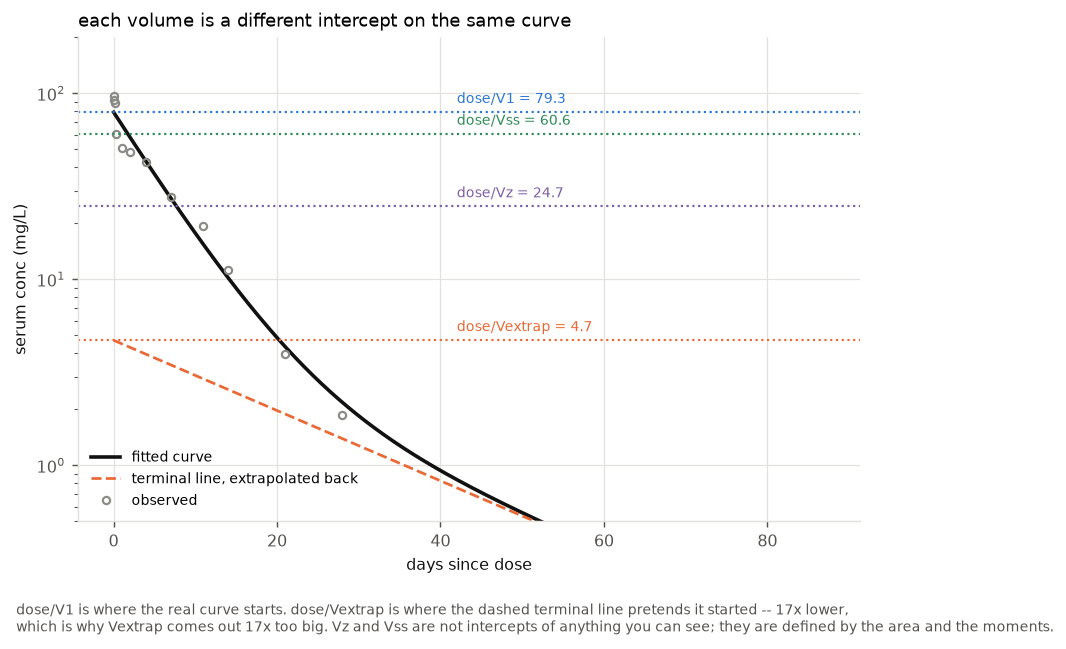

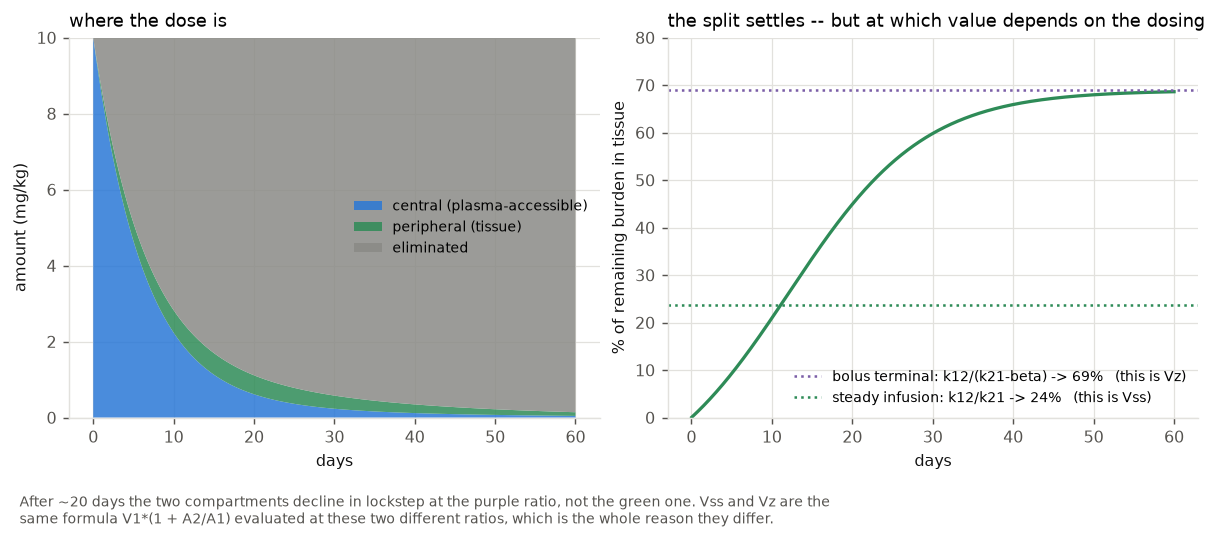

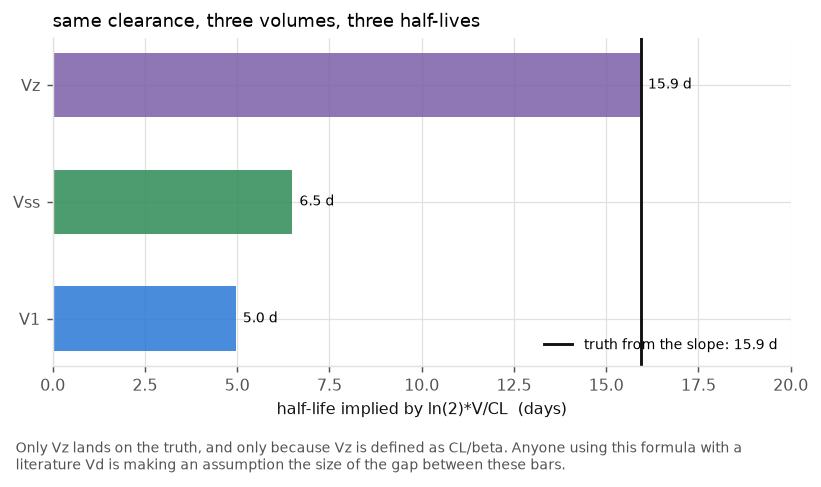

'/home/user/chiu__2022_rerun/tk_learning/figures/09_halflife_from_volume.png'

In [7]:
# E1 -- each volume as the intercept it corresponds to.
fig, ax = plt.subplots(figsize=(6.6, 4.4), constrained_layout=True)
tt = np.linspace(0.01, 60, 600)
ax.plot(tt, iv_2comp(tt, DOSE, V1, k10, k12, k21), color=P.INK, lw=2.0,
        label="fitted curve")
ax.plot(tt, B * np.exp(-beta * tt), "--", color=P.ORANGE, lw=1.5,
        label="terminal line, extrapolated back")
P.data_points(ax, t_obs, C_obs, color=P.GREY, label="observed", ms=4)
for nm, v, col in [("V1", V1, P.BLUE), ("Vss", Vss, P.GREEN),
                   ("Vz", Vz, P.PURPLE), ("Vextrap", Vextrap, P.ORANGE)]:
    ax.axhline(DOSE / v, color=col, lw=1.2, ls=":")
    ax.annotate(f"dose/{nm} = {DOSE/v:.1f}", (42, DOSE / v * 1.12),
                color=col, fontsize=8)
ax.set(yscale="log", ylim=(0.5, 200), xlabel="days since dose",
       ylabel="serum conc (mg/L)")
ax.set_title("each volume is a different intercept on the same curve")
ax.legend(loc="lower left", fontsize=8)
P.save(fig, "09_volume_intercepts.png",
       "dose/V1 is where the real curve starts. dose/Vextrap is where "
       "the dashed terminal line pretends it started -- 17x lower,\n"
       "which is why Vextrap comes out 17x too big. Vz and Vss are not "
       "intercepts of anything you can see; they are defined by the "
       "area and the moments.")

# E2 -- where the mass is, over time.
fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.6), constrained_layout=True)
a.stackplot(grid, A1, A2, elim,
            colors=[P.BLUE, P.GREEN, P.GREY], alpha=0.85,
            labels=["central (plasma-accessible)", "peripheral (tissue)",
                    "eliminated"])
a.set(xlabel="days", ylabel="amount (mg/kg)", ylim=(0, DOSE))
a.set_title("where the dose is")
a.legend(loc="center right", fontsize=7.5)
inbody = A1 + A2
b.plot(grid[1:], 100 * A2[1:] / inbody[1:], color=P.GREEN, lw=1.8)
b.axhline(100 * ratio_terminal / (1 + ratio_terminal), color=P.PURPLE,
          ls=":", lw=1.4,
          label=f"bolus terminal: k12/(k21-beta) -> "
                f"{100*ratio_terminal/(1+ratio_terminal):.0f}%   (this is Vz)")
b.axhline(100 * ratio_ss / (1 + ratio_ss), color=P.GREEN, ls=":", lw=1.4,
          label=f"steady infusion: k12/k21 -> "
                f"{100*ratio_ss/(1+ratio_ss):.0f}%   (this is Vss)")
b.set(xlabel="days", ylabel="% of remaining burden in tissue", ylim=(0, 80))
b.set_title("the split settles -- but at which value depends on the dosing")
b.legend(fontsize=7.5, loc="lower right")
P.save(fig, "09_where_the_mass_is.png",
       "After ~20 days the two compartments decline in lockstep at the "
       "purple ratio, not the green one. Vss and Vz are the\nsame "
       "formula V1*(1 + A2/A1) evaluated at these two different "
       "ratios, which is the whole reason they differ.")

# E3 -- the consequence: half-life from the wrong volume.
fig, ax = plt.subplots(figsize=(6.2, 3.2), constrained_layout=True)
names = ["V1", "Vss", "Vz"]
vals = [V1, Vss, Vz]
hl = [np.log(2) * v / CL for v in vals]
ax.barh(names, hl, color=[P.BLUE, P.GREEN, P.PURPLE], alpha=0.85, height=0.55)
ax.axvline(half_life(beta), color=P.INK, lw=1.6,
           label=f"truth from the slope: {half_life(beta):.1f} d")
for n, h in zip(names, hl):
    ax.annotate(f"{h:.1f} d", (h, n), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set(xlabel="half-life implied by ln(2)*V/CL  (days)", xlim=(0, 20))
ax.set_title("same clearance, three volumes, three half-lives")
ax.legend(loc="lower right", fontsize=8)
P.save(fig, "09_halflife_from_volume.png",
       "Only Vz lands on the truth, and only because Vz is defined as "
       "CL/beta. Anyone using this formula with a\nliterature Vd is "
       "making an assumption the size of the gap between these bars.")

### Questions

1. A chemical has Vd = 40 L/kg. Where is it? Can a volume of distribution exceed the volume of the animal, and what does it mean physically when it does?
1. Section A: why must Vss always be at least V1, and why must Vz always be at least Vss? Try to argue each from the definitions rather than from the numbers.
1. If you sampled this monkey for only 14 days instead of 87, which of CL, Vss and Vz would be worst affected? (Think about which integral each one needs.)
1. Chiu 2022 fitted Vd = 430 mL/kg for human PFOA from serum decay; Andersson 2025 measured 74 mL/kg by a different route. Before deciding one is wrong, what should you check about which VOLUME each was estimating?
1. The EPA animal paper found that Vd scales with body weight the way allometry predicts but clearance does not. Given Vss = V1 + V2 and CL = V1*k10, which of those two results is about anatomy and which is about biochemistry?

### Exercises

1. Refit on PFOS_Male_primate (2 mg/kg IV, 161 days) and compute all four volumes. PFOS binds serum protein more strongly than PFOA -- does its Vss come out smaller, as that would predict?
1. Truncate the monkey data at 28 days, refit, and recompute Vss and Vz. Quantify question 3.
1. Take the hierarchical two-compartment posterior from lesson 07 and compute Vss and Vz for every posterior draw. Which has the wider credible interval, and why?
1. Set k12 = k21 = 0 in the fitted parameters and recompute all four volumes. They should collapse to one number. Confirm that, and you have shown the two-compartment model contains the one-compartment model as a special case.